In [1]:
from google.colab import files
uploaded = files.upload()

Saving main-data-set-daily-4.csv to main-data-set-daily-4.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from itertools import product
import random

print("All libraries loaded successfully")

All libraries loaded successfully


In [4]:
!pip install scikit-learn

In [5]:
!pip install xgboost

In [6]:
!pip install tensorflow

In [7]:
!pip install scikit-learn xgboost lightgbm

In [14]:
from google.colab import files
uploaded = files.upload()

Saving main-data-set-daily-4-fixed.xlsx to main-data-set-daily-4-fixed.xlsx


In [15]:
df["midday"] = df["midday"].astype(str).str.zfill(4)
df["evening"] = df["evening"].astype(str).str.zfill(4)

In [16]:
midday_numbers = df["midday"].dropna().tolist()
evening_numbers = df["evening"].dropna().tolist()

print(midday_numbers[:10])

['6276', '8276', '1514', '3421', '2865', '6389', '0511', '2681', '7436', '6607']


In [17]:
import pandas as pd
import numpy as np

df = pd.read_csv("main-data-set-daily-4.csv")

# Clean column names (fix 'evening ' trailing space)
df.columns = df.columns.str.strip().str.lower()

# Make sure required columns exist
print("Columns:", df.columns.tolist())
assert "midday" in df.columns, "Missing column: midday"
assert "evening" in df.columns, "Missing column: evening"

# Keep leading zeros as 4-char strings
df["midday"] = df["midday"].astype(str).str.zfill(4)
df["evening"] = df["evening"].astype(str).str.zfill(4)

# Create a date if not present (from year/month/day)
df["year"] = df["year"].astype(int)
df["month"] = df["month"].astype(int)
df["day"] = df["day"].astype(int)

df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=df["day"]), errors="coerce")
df = df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

df.head()

Columns: ['year', 'month', 'day', 'dayname', 'midday', 'evening']


,year,month,day,dayname,midday,evening,date
0,2021,1,1,Friday,6276,4206.0,2021-01-01
1,2021,1,2,Saturday,8276,3380.0,2021-01-02
2,2021,1,3,Sunday,1514,9468.0,2021-01-03
3,2021,1,4,Monday,3421,3045.0,2021-01-04
4,2021,1,5,Tuesday,2865,4898.0,2021-01-05


In [18]:
TARGET_DRAW = "midday"  # change to "evening" if you want

target_series = df[TARGET_DRAW].copy()
print("Using target:", TARGET_DRAW)
print("Rows:", len(target_series))

Using target: midday
Rows: 1879


In [19]:
L = 10  # number of previous draws used as features (try 5,10,20)

# Split target into 4 digit columns
digits = target_series.apply(lambda s: list(s))
digits = pd.DataFrame(digits.tolist(), columns=["d0","d1","d2","d3"])
for c in digits.columns:
    digits[c] = digits[c].astype(int)

data = pd.concat([df[["date","year","month","day"]], digits], axis=1)

# Date features
data["dow"] = data["date"].dt.dayofweek  # 0=Mon
data["weekofyear"] = data["date"].dt.isocalendar().week.astype(int)

# Lag features: previous digits
for lag in range(1, L+1):
    for pos in ["d0","d1","d2","d3"]:
        data[f"{pos}_lag{lag}"] = data[pos].shift(lag)

# Drop rows without enough history
data = data.dropna().reset_index(drop=True)

# X features and y labels (4 positions)
feature_cols = [c for c in data.columns if c.startswith("d") and "lag" in c] + ["month","day","dow","weekofyear"]
X = data[feature_cols].astype(int)

Y = {
    0: data["d0"].astype(int),
    1: data["d1"].astype(int),
    2: data["d2"].astype(int),
    3: data["d3"].astype(int),
}

print("Feature shape:", X.shape)
print("Example features:", feature_cols[:8], "...")

Feature shape: (1869, 44)
Example features: ['d0_lag1', 'd1_lag1', 'd2_lag1', 'd3_lag1', 'd0_lag2', 'd1_lag2', 'd2_lag2', 'd3_lag2'] ...


In [20]:
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
Y_train = {k: v.iloc[:split] for k,v in Y.items()}
Y_test  = {k: v.iloc[split:] for k,v in Y.items()}

print("Train:", len(X_train), "Test:", len(X_test))
print("Test date range:", data["date"].iloc[split].date(), "to", data["date"].iloc[-1].date())

Train: 1495 Test: 374
Test date range: 2025-02-14 to 2026-02-22


In [21]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import CategoricalNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier

models = {
    "Dummy(most_frequent)": DummyClassifier(strategy="most_frequent"),
    "LogReg(multinomial)": LogisticRegression(max_iter=2000, multi_class="auto"),
    "CategoricalNB": CategoricalNB(alpha=1.0),
    "KNN(k=25)": KNeighborsClassifier(n_neighbors=25),
    "LinearSVC": LinearSVC(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=400, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "MLP(128,64)": MLPClassifier(hidden_layer_sizes=(128,64), max_iter=500, random_state=42),
    "MLP(256,128)": MLPClassifier(hidden_layer_sizes=(256,128), max_iter=500, random_state=42),
}
len(models)

12

In [22]:
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

def evaluate_model(model_name, base_model):
    # Train 4 separate classifiers, one per digit position
    preds = {}
    accs = []
    for pos in range(4):
        m = base_model
        # some models need a fresh instance per fit
        import copy
        m = copy.deepcopy(m)

        m.fit(X_train, Y_train[pos])
        yhat = m.predict(X_test)
        preds[pos] = yhat
        accs.append(accuracy_score(Y_test[pos], yhat))

    # exact 4-digit accuracy = all positions correct
    exact = np.mean(
        (preds[0]==Y_test[0].values) &
        (preds[1]==Y_test[1].values) &
        (preds[2]==Y_test[2].values) &
        (preds[3]==Y_test[3].values)
    )

    return {
        "model": model_name,
        "digit_acc_avg": float(np.mean(accs)),
        "pos0_acc": accs[0],
        "pos1_acc": accs[1],
        "pos2_acc": accs[2],
        "pos3_acc": accs[3],
        "exact_4digit_acc": float(exact),
    }

results = []
for name, m in models.items():
    print("Running:", name)
    results.append(evaluate_model(name, m))

res_df = pd.DataFrame(results).sort_values(["exact_4digit_acc","digit_acc_avg"], ascending=False)
res_df

Running: Dummy(most_frequent)
Running: LogReg(multinomial)
Running: CategoricalNB
Running: KNN(k=25)
Running: LinearSVC
Running: DecisionTree
Running: RandomForest
Running: ExtraTrees
Running: GradientBoosting
Running: AdaBoost
Running: MLP(128,64)
Running: MLP(256,128)


,model,digit_acc_avg,pos0_acc,pos1_acc,pos2_acc,pos3_acc,exact_4digit_acc
8,GradientBoosting,0.106952,0.098930,0.088235,0.120321,0.120321,0.0
6,RandomForest,0.105615,0.101604,0.096257,0.106952,0.117647,0.0
10,"MLP(128,64)",0.102941,0.114973,0.088235,0.112299,0.096257,0.0
11,"MLP(256,128)",0.101604,0.120321,0.109626,0.090909,0.085561,0.0
0,Dummy(most_frequent),0.100267,0.104278,0.096257,0.096257,0.104278,0.0
7,ExtraTrees,0.099599,0.128342,0.093583,0.077540,0.098930,0.0
5,DecisionTree,0.096257,0.106952,0.082888,0.082888,0.112299,0.0
9,AdaBoost,0.093583,0.098930,0.088235,0.101604,0.085561,0.0
1,LogReg(multinomial),0.092914,0.096257,0.093583,0.082888,0.098930,0.0
3,KNN(k=25),0.092246,0.093583,0.098930,0.090909,0.085561,0.0


,model,digit_acc_avg,exact_4digit_acc,pos0_acc,pos1_acc,pos2_acc,pos3_acc
8,GradientBoosting,0.106952,0.0,0.098930,0.088235,0.120321,0.120321
6,RandomForest,0.105615,0.0,0.101604,0.096257,0.106952,0.117647
10,"MLP(128,64)",0.102941,0.0,0.114973,0.088235,0.112299,0.096257
11,"MLP(256,128)",0.101604,0.0,0.120321,0.109626,0.090909,0.085561
0,Dummy(most_frequent),0.100267,0.0,0.104278,0.096257,0.096257,0.104278
7,ExtraTrees,0.099599,0.0,0.128342,0.093583,0.077540,0.098930
5,DecisionTree,0.096257,0.0,0.106952,0.082888,0.082888,0.112299
9,AdaBoost,0.093583,0.0,0.098930,0.088235,0.101604,0.085561
1,LogReg(multinomial),0.092914,0.0,0.096257,0.093583,0.082888,0.098930
3,KNN(k=25),0.092246,0.0,0.093583,0.098930,0.090909,0.085561


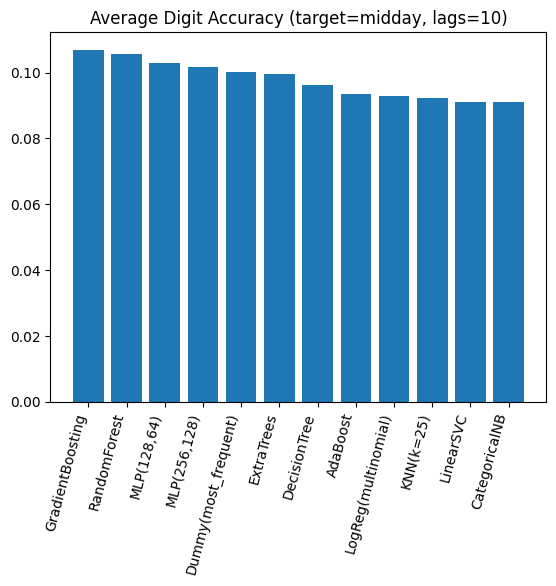

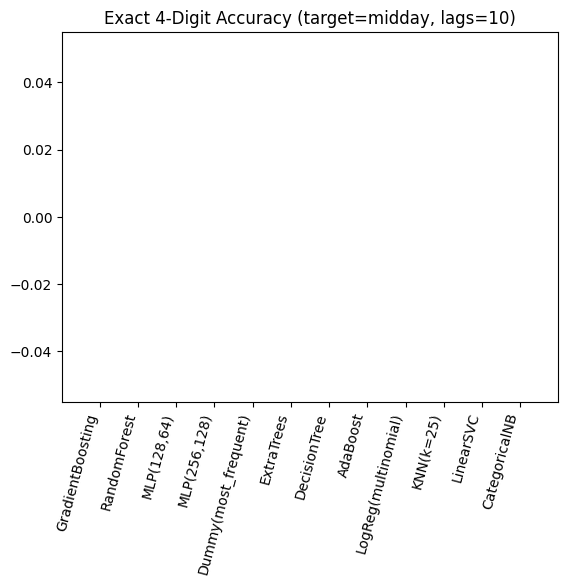

In [23]:
import matplotlib.pyplot as plt

display(res_df[["model","digit_acc_avg","exact_4digit_acc","pos0_acc","pos1_acc","pos2_acc","pos3_acc"]])

plt.figure()
plt.bar(res_df["model"], res_df["digit_acc_avg"])
plt.xticks(rotation=75, ha="right")
plt.title(f"Average Digit Accuracy (target={TARGET_DRAW}, lags={L})")
plt.show()

plt.figure()
plt.bar(res_df["model"], res_df["exact_4digit_acc"])
plt.xticks(rotation=75, ha="right")
plt.title(f"Exact 4-Digit Accuracy (target={TARGET_DRAW}, lags={L})")
plt.show()

In [24]:
best_name = res_df.iloc[0]["model"]
best_model = models[best_name]
print("Best model:", best_name)

# Build a single row of features for the most recent available date in data
X_last = X.iloc[[-1]]

import copy
pred_digits = []
for pos in range(4):
    m = copy.deepcopy(best_model)
    m.fit(X_train, Y_train[pos])
    pred_digits.append(int(m.predict(X_last)[0]))

predicted_number = "".join(map(str, pred_digits))
print("Predicted next number (model-based):", predicted_number)
print("Last known draw date in data:", data['date'].iloc[-1].date())

Best model: GradientBoosting
Predicted next number (model-based): 5399
Last known draw date in data: 2026-02-22
